<a href="https://colab.research.google.com/github/ucaokylong/Some_small_projects/blob/main/DCGAN_emoji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn, Tensor
import numpy as np
from torchvision.utils import save_image

torch.manual_seed(0)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [2]:
!pip3 install -q datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12=

# 1. Dataset

In [3]:
from torch.utils.data import Dataset
import torchvision
from datasets import load_dataset

img_size = 64

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((img_size, img_size)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                     std=[0.5, 0.5, 0.5])
])

hf_emoji_dataset = load_dataset("valhalla/emoji-dataset")

class EmojiDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example["image"]
        label = example["text"]

        if self.transform:
            image = self.transform(image)

        return image, label


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

(…)-00000-of-00001-38cc4fa96c139e86.parquet:   0%|          | 0.00/139M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2749 [00:00<?, ? examples/s]

In [4]:
BATCH_SIZE = 128

train_dataset = EmojiDataset(hf_emoji_dataset["train"], transform=transform)
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Model

In [5]:
channels = 3
img_shape = (channels, img_size, img_size)
latent_dim=100

In [6]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, z_dim=100, hidden_dim=64, channels=3):
        super().__init__()
        self.up_block1 = nn.Sequential(
            nn.ConvTranspose2d(z_dim, hidden_dim * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(hidden_dim * 8),
            nn.ReLU(inplace=True)
        )

        self.up_block2 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 8, hidden_dim * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 4),
            nn.ReLU(inplace=True)
        )

        self.up_block3 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim*2),
            nn.ReLU(inplace=True)
        )

        self.up_block4 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim*2, hidden_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True)
        )

        self.up_block5 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise):
        out1 = self.up_block1(noise)
        out2 = self.up_block2(out1)
        out3 = self.up_block3(out2)
        out4 = self.up_block4(out3)
        out5 = self.up_block5(out4)
        return out5


In [7]:
# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, input_dim=3, hidden_dim = 64):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_dim, hidden_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim*2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(hidden_dim*2, hidden_dim*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim*4),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(hidden_dim*4, hidden_dim*8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim*8),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv_block5 = nn.Sequential(
            nn.Conv2d(hidden_dim*8, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, image):
        out1 = self.conv_block1(image)
        out2 = self.conv_block2(out1)
        out3 = self.conv_block3(out2)
        out4 = self.conv_block4(out3)
        out5 = self.conv_block5(out4)
        return out5

In [8]:
generator = Generator()
discriminator = Discriminator()

In [9]:
generator.to(device)

Generator(
  (up_block1): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up_block2): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up_block3): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up_block4): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up_block5): Sequ

In [10]:
discriminator.to(device)

Discriminator(
  (conv_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv_block3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv_block4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv_block5): Se

# 3. Training

In [11]:
import os
OUTPUT = "dcgan_emoji_output"

# # clear all images
# for f in os.listdir(OUTPUT):
#     os.remove(os.path.join(OUTPUT, f))

os.makedirs(OUTPUT, exist_ok=True)

save_interval = 10

In [12]:
EPOCHS = 10

criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


hist = {
        "train_G_loss": [],
        "train_D_loss": [],
    }

for epoch in range(EPOCHS):
    running_G_loss = 0.0
    running_D_loss = 0.0

    for i, (imgs, _) in enumerate(dataloader):

        real_imgs = imgs.to(device)

        valid = torch.full((imgs.shape[0], ), 1.0, device=device)
        fake = torch.full((imgs.shape[0], ), 0.0, device=device)


        # --- Train Generator ---
        optimizer_G.zero_grad()
        # Noise input for Generator
        z = Tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim, 1, 1))).to(device)

        gen_imgs = generator(z)
        G_loss = criterion(discriminator(gen_imgs).view(-1), valid)
        running_G_loss += G_loss.item()

        G_loss.backward()
        optimizer_G.step()

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_imgs).view(-1), valid)
        fake_loss = criterion(discriminator(gen_imgs.detach()).view(-1), fake)
        D_loss = (real_loss + fake_loss) / 2
        running_D_loss += D_loss.item()

        D_loss.backward()
        optimizer_D.step()


    epoch_G_loss = running_G_loss / len(dataloader)
    epoch_D_loss = running_D_loss / len(dataloader)

    print(f"Epoch [{epoch + 1}/{EPOCHS}], Train G Loss: {epoch_G_loss:.4f}, Train D Loss: {epoch_D_loss:.4f}")

    hist["train_G_loss"].append(epoch_G_loss)
    hist["train_D_loss"].append(epoch_D_loss)

    save_image(gen_imgs.data[:25], f"{OUTPUT}/epoch_{epoch}.png", nrow=5, normalize=True)


Epoch [1/10], Train G Loss: 4.6977, Train D Loss: 0.0798
Epoch [2/10], Train G Loss: 11.6184, Train D Loss: 0.0283
Epoch [3/10], Train G Loss: 15.0102, Train D Loss: 0.1329
Epoch [4/10], Train G Loss: 14.9352, Train D Loss: 0.1473
Epoch [5/10], Train G Loss: 14.4290, Train D Loss: 0.1281
Epoch [6/10], Train G Loss: 11.1174, Train D Loss: 0.0840
Epoch [7/10], Train G Loss: 8.2074, Train D Loss: 0.1994
Epoch [8/10], Train G Loss: 4.5683, Train D Loss: 0.2972
Epoch [9/10], Train G Loss: 2.6915, Train D Loss: 0.1770
Epoch [10/10], Train G Loss: 2.5176, Train D Loss: 0.1812


In [13]:
# save model ckpt
torch.save(generator.state_dict(), "dcgan_emoji_generator.pth")
torch.save(discriminator.state_dict(), "dcgan_emoji_discriminator.pth")

Displaying a few generated images:


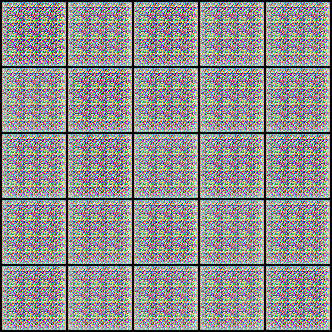

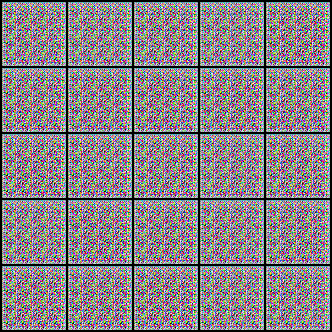

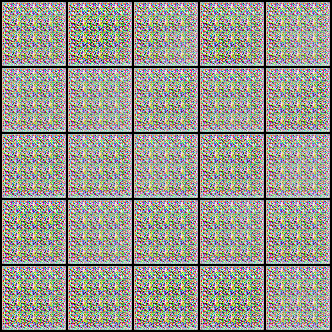

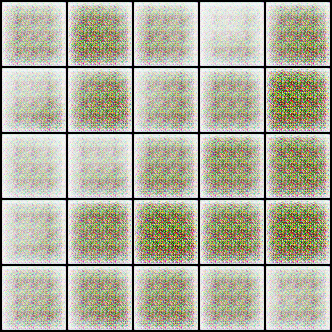

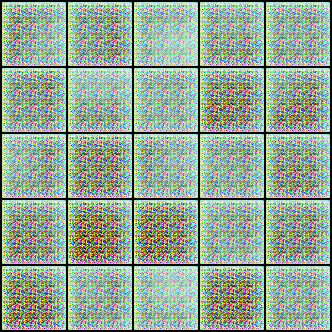

In [18]:
import os
import glob
from PIL import Image
from IPython.display import display, Image as IPImage
# Get all epoch images sorted by number
image_files = sorted(glob.glob(os.path.join(OUTPUT, "epoch_*.png")),
                     key=lambda x: int(os.path.basename(x).split("_")[1].split(".")[0]))

# Load images
images = [Image.open(img) for idx, img in enumerate(image_files) if idx % 5 == 0]

# Determine grid size
num_images = len(images)
cols = 5
# Ensure rows is at least 1 to avoid negative grid_height
rows = max(1, num_images // cols)

# Image size (assumes all images are the same size)
# Handle case where there are no images
if not images:
    print("No images found to create a grid.")
    exit()  # Or handle differently, like creating a blank image
else:
    img_width, img_height = images[0].size

padding = 10  # Space between images

# Calculate total canvas size
grid_width = cols * img_width + (cols - 1) * padding
grid_height = rows * img_height + (rows - 1) * padding

# Create a blank canvas
grid_img = Image.new("RGB", (grid_width, grid_height), "white")

# Paste images into the grid with padding
for i, img in enumerate(images):
    x = (i % cols) * (img_width + padding)
    y = (i // cols) * (img_height + padding)
    grid_img.paste(img, (x, y))

# Save and show the final grid image
grid_img.save("dcgan_emoji_grid.png")
grid_img.show()

# Display a few images in the output folder
print("Displaying a few generated images:")
# Get a list of all PNG files in the output folder
image_files = glob.glob(os.path.join(OUTPUT, "*.png"))
# Display only the first 5 images (you can adjust this number)
for image_file in image_files[:5]:
    display(IPImage(filename=image_file))